# Logistic Regression for Return Direction Prediction

**Docker image**: `ml4t`

**Purpose**: apply logistic regression to predict the direction of 21-day forward
returns on the ETF panel, using the same walk-forward folds as
`02_regularization_paths`.

**Learning objectives**

- Convert a continuous return label into a binary classification target
- Fit L2- and L1-regularized logistic regression on walk-forward folds
- Evaluate with classification metrics: accuracy, AUC-ROC, precision, recall
- Assess probability calibration and its importance for position sizing
- Compare feature importance from L1 logistic coefficients

**Book reference**: Section 11.3 - Predicting Direction with Logistic Regression.

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- Walk-forward CV configuration in `case_studies/etfs/config/setup.yaml`

**Downstream**: `04_nested_cv_hpo` (HPO with nested CV), `06_conformal_prediction`
(uncertainty quantification), Ch12 (gradient boosting on the same task).

## Setup

In [1]:
"""Logistic Regression for Return Direction Prediction - classify direction and calibration."""

import hashlib
import inspect
import json
import warnings
from importlib.metadata import version

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import sklearn
from IPython.display import Markdown, display
from matplotlib.patches import Patch
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir, get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
RETRAIN = False

In [3]:
RANDOM_SEED = SEED
LABEL_HORIZON_SESSIONS = 21
OUTER_LABEL_BUFFER = "21D"
L2_C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
L1_C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0]
MODEL_MAX_ITER = 1000
CACHE_SCHEMA_VERSION = 2
set_global_seeds(SEED)

## Load Features and Labels

We reuse the same pre-computed features (Ch8) and 21-day forward return labels
(Ch7) as `02_regularization_paths`. The only difference is that we convert the
continuous return into a binary direction target.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

### Create Binary Direction Target

We convert the continuous 21-day forward return into a binary label:
1 if the return is positive (up), 0 otherwise (down). This transforms
the regression problem from NB02 into a classification problem.

In [5]:
RETURN_COL = "fwd_ret_21d"
TARGET_COL = "direction"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner").with_columns(
    (pl.col(RETURN_COL) > 0).cast(pl.Int32).alias(TARGET_COL),
)

META_COLS = {"timestamp", ASSET_COL, RETURN_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 393,985 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


### Class Balance

A significant imbalance would require stratified sampling or reweighting.
With 21-day returns on diversified ETFs over a long-term bull market, we
expect a moderate positive skew.

In [6]:
up_count = df.filter(pl.col(TARGET_COL) == 1).height
down_count = df.filter(pl.col(TARGET_COL) == 0).height
print(f"Up (1):   {up_count:>8,}  ({up_count / df.height:.1%})")
print(f"Down (0): {down_count:>8,}  ({down_count / df.height:.1%})")

Up (1):    233,818  (59.3%)
Down (0):  160,167  (40.7%)


## Walk-Forward Cross-Validation Setup

We reuse the same walk-forward splits from `setup.yaml` as
`02_regularization_paths`: rolling train/validation windows with purge gap.

In [7]:
splits = sorted(
    generate_cv_splits(
        df,
        case_study_id="etfs",
        label_buffer=OUTER_LABEL_BUFFER,
        date_col="timestamp",
    ),
    key=lambda split: split["val_start"],
)

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
return_array = df[RETURN_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()

cv_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    cv_splits.append((train_idx, test_idx))

train_sizes = [len(tr) for tr, _ in cv_splits]
test_sizes = [len(te) for _, te in cv_splits]
if cv_splits:
    print(
        f"{len(cv_splits)} walk-forward folds - train size "
        f"{min(train_sizes):,}-{max(train_sizes):,}, validation size "
        f"{min(test_sizes):,}-{max(test_sizes):,}"
    )
else:
    print("0 walk-forward folds - every candidate split failed the train/validation size gate")

8 walk-forward folds - train size 157,172-226,959, validation size 22,170-24,192


## Helper Functions

### Solver Selection

sklearn's `LogisticRegression` offers several solvers optimized for different
penalty structures:

| Solver | L1 | L2 | ElasticNet | Multinomial | Best for |
|------------|----|----|------------|-------------|----------------------------------------------|
| `lbfgs` | no | yes | no | yes | Default L2; fast quasi-Newton |
| `liblinear` | yes | yes | no | no | Pure L1 binary; coordinate descent |
| `saga` | yes | yes | yes | yes | ElasticNet, large $n$, `sample_weight` |

We use `lbfgs` for L2 (fast, numerically stable), `liblinear` for pure L1
binary classification, and `saga` only when ElasticNet mixing is needed.

In [8]:
def evaluate_classification(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Classification metrics: accuracy, precision, recall, F1, AUC-ROC, log-loss."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        "log_loss": log_loss(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

### Logistic Estimator

Penalty-specific solver choices live in one constructor so the cache signature
and every fold share the same training contract.

In [9]:
def build_logistic_model(l1_ratio: float, C: float) -> LogisticRegression:
    """Construct the penalty-specific logistic estimator."""
    if l1_ratio == 0.0:
        penalty, solver = "l2", "lbfgs"
        model_kwargs = {}
    elif l1_ratio == 1.0:
        penalty, solver = "l1", "liblinear"
        model_kwargs = {}
    else:
        penalty, solver = "elasticnet", "saga"
        model_kwargs = {"l1_ratio": l1_ratio}
    return LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        max_iter=MODEL_MAX_ITER,
        random_state=RANDOM_SEED,
        **model_kwargs,
    )

### One Walk-Forward Fold

Every fold learns preprocessing and model state from its training rows only.

In [10]:
def fit_logistic_fold(
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    l1_ratio: float,
    C: float,
) -> tuple[dict, np.ndarray, dict, dict]:
    """Fit and evaluate one chronological fold."""
    X_tr, X_te = features_array[train_idx], features_array[test_idx]
    y_tr, y_te = target_array[train_idx], target_array[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = build_logistic_model(l1_ratio, C)
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    metrics = evaluate_classification(y_te, y_pred, y_prob)
    prediction = {
        "y_true": y_te,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "returns": return_array[test_idx],
    }
    return metrics, model.coef_.ravel().copy(), prediction, {"model": model, "scaler": scaler}

### Walk-Forward Logistic CV

The wrapper collects fold metrics, predictions, coefficients, and fitted state.

In [11]:
def cross_validate_logistic(
    l1_ratio: float = 0.0,
    C: float = 1.0,
) -> tuple[list[dict], list[np.ndarray], list[dict], list[dict]]:
    """Run logistic regression on every walk-forward fold."""
    results, coefficients, predictions, fold_models = [], [], [], []

    for i, (train_idx, test_idx) in enumerate(cv_splits):
        metrics, coefficient, prediction, fold_model = fit_logistic_fold(
            train_idx,
            test_idx,
            l1_ratio,
            C,
        )
        metrics["fold"] = i + 1
        results.append(metrics)
        coefficients.append(coefficient)
        predictions.append(prediction)
        fold_models.append(fold_model)

    return results, coefficients, predictions, fold_models

## Model Cache

Training results are cached to disk so subsequent runs skip model fitting.
Its signature binds the cleaned arrays, split state, model configuration, source
implementation, and relevant library versions. Any semantic change therefore
triggers a genuine retrain rather than silently reusing stale predictions.
Set `RETRAIN = True` to force retraining even when the hashes match.

A content hash makes the cache dependency explicit and portable across machines.

In [12]:
def file_sha256(path) -> str:
    """Return the SHA-256 digest for an input artifact."""
    with path.open("rb") as file:
        return hashlib.file_digest(file, "sha256").hexdigest()

Array hashes cover filtering, symbol limits, row order, feature order, and cleaning
semantics after the two source files have been joined.

In [13]:
def array_sha256(array: np.ndarray) -> str:
    """Hash array shape, dtype, and contiguous values."""
    contiguous = np.ascontiguousarray(array)
    digest = hashlib.sha256()
    digest.update(str(contiguous.dtype).encode())
    digest.update(repr(contiguous.shape).encode())
    digest.update(contiguous.tobytes())
    return digest.hexdigest()

In [14]:
def canonical_sha256(payload: dict) -> str:
    """Hash a nested contract with stable key ordering and date serialization."""
    serialized = json.dumps(payload, sort_keys=True, default=str).encode()
    return hashlib.sha256(serialized).hexdigest()


def assess_cache(cached: dict, expected_signature: dict) -> tuple[list[str], bool]:
    """Return missing result keys and whether the training signature matches."""
    required = {"l2_all", "l2_summary", "best_l2_C", "l1_all", "l1_summary", "best_l1_C"}
    return sorted(required - set(cached)), cached.get("input_signature") == expected_signature

The training contract records every choice that can change fitted predictions.
A canonical digest keeps the cache comparison compact and deterministic.

In [15]:
RESULTS_DIR = get_output_dir(11, "03_logistic_classification")
RESULTS_PATH = RESULTS_DIR / "cv_results.joblib"
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"
cv_indices = np.concatenate(
    [np.concatenate([train_idx, [-1], test_idx, [-2]]) for train_idx, test_idx in cv_splits]
).astype(np.int64)

The data and split contracts include both declared configuration and the resolved
rows. This catches changes in cleaning, symbol limits, calendar mapping, or fold order.

In [16]:
DATA_CONTRACT = {
    "case_study_id": "etfs",
    "date_column": "timestamp",
    "symbol_column": ASSET_COL,
    "return_column": RETURN_COL,
    "target_column": TARGET_COL,
    "target_rule": "direction = int(fwd_ret_21d > 0)",
    "feature_columns": FEATURE_COLS,
    "cleaning": "inner join; drop all-null features; finite-only; drop nulls; sort date-symbol",
    "scaling": "fold-local StandardScaler fit on training rows only",
    "max_symbols": MAX_SYMBOLS,
    "symbol_subset": "sorted unique symbols, first max_symbols; zero means all",
}
SPLIT_CONTRACT = {
    "source_config_sha256": file_sha256(SETUP_PATH),
    "label_buffer": OUTER_LABEL_BUFFER,
    "label_horizon_sessions": LABEL_HORIZON_SESSIONS,
    "direction": "chronological ascending after sort by val_start",
    "resolved_windows": splits,
    "resolved_indices_sha256": array_sha256(cv_indices),
}

The model contract binds optimization, deterministic selection, implementation
source, and relevant dependency versions.

In [17]:
MODEL_CONTRACT = {
    "l2": {"C": L2_C_VALUES, "l1_ratio": 0.0, "penalty": "l2", "solver": "lbfgs"},
    "l1": {"C": L1_C_VALUES, "l1_ratio": 1.0, "penalty": "l1", "solver": "liblinear"},
    "max_iter": MODEL_MAX_ITER,
    "random_seed": RANDOM_SEED,
    "selection": {
        "metric": "mean fold AUC-ROC",
        "aggregation": "unweighted arithmetic mean across folds",
        "direction": "maximize",
        "tie_break": "smallest C",
    },
}

In [18]:
TRAINING_CONTRACT = {
    "schema_version": CACHE_SCHEMA_VERSION,
    "data": DATA_CONTRACT,
    "splits": SPLIT_CONTRACT,
    "models": MODEL_CONTRACT,
    "implementation": {
        "notebook_source_sha256": file_sha256(
            get_chapter_dir(11) / "03_logistic_classification.py"
        ),
        "splitter_source_sha256": hashlib.sha256(
            inspect.getsource(generate_cv_splits).encode()
        ).hexdigest(),
    },
    "versions": {
        "numpy": np.__version__,
        "polars": pl.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "ml4t_diagnostic": version("ml4t-diagnostic"),
        "exchange_calendars": version("exchange-calendars"),
        "pandas_market_calendars": version("pandas-market-calendars"),
    },
}

Input hashes bind the contract to the exact cleaned arrays. The complete contract
remains inside the cache so a verifier can inspect what produced each result.

In [19]:
TRAINING_CONTRACT_SHA256 = canonical_sha256(TRAINING_CONTRACT)
INPUT_SIGNATURE = {
    "training_contract_sha256": TRAINING_CONTRACT_SHA256,
    "features_sha256": file_sha256(FEATURES_PATH),
    "labels_sha256": file_sha256(LABELS_PATH),
    "features_array_sha256": array_sha256(features_array),
    "target_array_sha256": array_sha256(target_array),
    "return_array_sha256": array_sha256(return_array),
    "dates_sha256": array_sha256(dates_np),
    "training_contract": TRAINING_CONTRACT,
}

In [20]:
NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()

if not NEED_TRAINING:
    _cached = joblib.load(RESULTS_PATH)
    missing_keys, signature_matches = assess_cache(_cached, INPUT_SIGNATURE)
    NEED_TRAINING = bool(missing_keys or not signature_matches)
    if NEED_TRAINING:
        reason = f"missing keys {missing_keys}" if missing_keys else "training signature changed"
        print(f"Ignoring stale model cache: {reason}.")
    else:
        l2_all = _cached["l2_all"]
        l2_summary = _cached["l2_summary"]
        best_l2_C = _cached["best_l2_C"]
        l1_all = _cached["l1_all"]
        l1_summary = _cached["l1_summary"]
        best_l1_C = _cached["best_l1_C"]
        print(f"  L2: {len(l2_all)} C values | L1: {len(l1_all)} C values")
    del _cached
if NEED_TRAINING:
    print("Training models (RETRAIN=True or no cache found)...")

  L2: 6 C values | L1: 5 C values


## L2 Regularized Logistic Regression (Ridge)

The regularization parameter $C$ is the *inverse* of penalty strength:
small $C$ means strong regularization. We sweep six values from heavy
($C=0.001$) to light ($C=100$) regularization.

In [21]:
if NEED_TRAINING:
    l2_all = {}
    for C in L2_C_VALUES:
        res, coeffs, preds, models = cross_validate_logistic(l1_ratio=0.0, C=C)
        l2_all[C] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "predictions": preds,
            "models": models,
        }

    l2_summary = pl.DataFrame(
        [
            {
                "C": C,
                "mean_acc": d["results"]["accuracy"].mean(),
                "mean_auc": d["results"]["auc_roc"].mean(),
                "mean_f1": d["results"]["f1"].mean(),
            }
            for C, d in l2_all.items()
        ]
    ).sort(["mean_auc", "C"], descending=[True, False])

    best_l2_C = l2_summary.row(0, named=True)["C"]

In [22]:
print(
    f"Best L2 C: {best_l2_C}  AUC: {l2_summary.filter(pl.col('C') == best_l2_C)['mean_auc'].item():.4f}"
)
l2_summary

Best L2 C: 0.01  AUC: 0.5242


C,mean_acc,mean_auc,mean_f1
f64,f64,f64,f64
0.01,0.534037,0.52419,0.616073
0.001,0.540096,0.523759,0.631248
100.0,0.532901,0.523713,0.61375
1.0,0.532768,0.523702,0.6136
0.1,0.53297,0.523383,0.614229
10.0,0.532846,0.523339,0.613647


### Effect of Class Weighting

`class_weight='balanced'` scales each class's loss contribution inversely
by its frequency. We evaluate the unweighted and balanced objectives on the
latest walk-forward fold. This comparison isolates the effect of weighting
while keeping the training window, regularization, and decision threshold fixed.

In [23]:
train_idx_cw, test_idx_cw = cv_splits[-1]
scaler_cw = StandardScaler()
X_tr_cw = scaler_cw.fit_transform(features_array[train_idx_cw])
X_te_cw = scaler_cw.transform(features_array[test_idx_cw])
y_tr_cw, y_te_cw = target_array[train_idx_cw], target_array[test_idx_cw]

rows_cw = []
for cw_label, cw_val in [("None", None), ("Balanced", "balanced")]:
    m = LogisticRegression(
        C=best_l2_C,
        solver="lbfgs",
        max_iter=MODEL_MAX_ITER,
        random_state=RANDOM_SEED,
        class_weight=cw_val,
    )
    m.fit(X_tr_cw, y_tr_cw)
    yp = m.predict_proba(X_te_cw)[:, 1]
    rows_cw.append(
        {
            "class_weight": cw_label,
            **evaluate_classification(y_te_cw, (yp >= 0.5).astype(int), yp),
        }
    )

cw_df = pl.DataFrame(rows_cw)
cw_df

class_weight,accuracy,precision,recall,f1,auc_roc,log_loss
str,f64,f64,f64,f64,f64,f64
"""None""",0.521372,0.573885,0.491097,0.529273,0.543179,0.698839
"""Balanced""",0.502026,0.66722,0.181832,0.285782,0.543618,0.730799


The result below is generated from the current run so a new data vintage cannot
leave a stale class-balance claim behind.

In [24]:
cw_default, cw_balanced = cw_df.iter_rows(named=True)
display(
    Markdown(
        f"The balanced objective changes majority-class recall from "
        f"**{cw_default['recall']:.3f}** to **{cw_balanced['recall']:.3f}** and F1 from "
        f"**{cw_default['f1']:.3f}** to **{cw_balanced['f1']:.3f}**, while AUC moves only "
        f"from **{cw_default['auc_roc']:.3f}** to **{cw_balanced['auc_roc']:.3f}**. "
        "Class weighting therefore changes the fitted decision rule materially even when "
        "rank discrimination changes little."
    )
)

The balanced objective changes majority-class recall from **0.491** to **0.182** and F1 from **0.529** to **0.286**, while AUC moves only from **0.543** to **0.544**. Class weighting therefore changes the fitted decision rule materially even when rank discrimination changes little.

## L1 Regularized Logistic Regression (LASSO)

L1 regularization drives some coefficients to exactly zero, performing
automatic feature selection - the same sparsity effect we saw with LASSO
regression in NB02.

In [25]:
if NEED_TRAINING:
    l1_all = {}
    for C in L1_C_VALUES:
        res, coeffs, preds, models = cross_validate_logistic(l1_ratio=1.0, C=C)
        l1_all[C] = {
            "results": pl.DataFrame(res),
            "coeffs": np.array(coeffs),
            "predictions": preds,
            "models": models,
        }

    l1_summary = pl.DataFrame(
        [
            {
                "C": C,
                "mean_acc": d["results"]["accuracy"].mean(),
                "mean_auc": d["results"]["auc_roc"].mean(),
                "mean_f1": d["results"]["f1"].mean(),
                "n_nonzero": int((np.abs(d["coeffs"]).mean(axis=0) > 1e-8).sum()),
            }
            for C, d in l1_all.items()
        ]
    ).sort(["mean_auc", "C"], descending=[True, False])

    best_l1_C = l1_summary.row(0, named=True)["C"]

In [26]:
print(
    f"Best L1 C: {best_l1_C}  AUC: {l1_summary.filter(pl.col('C') == best_l1_C)['mean_auc'].item():.4f}"
)
l1_summary

Best L1 C: 10.0  AUC: 0.5234


C,mean_acc,mean_auc,mean_f1,n_nonzero
f64,f64,f64,f64,i64
10.0,0.532811,0.523406,0.613641,57
1.0,0.532764,0.523389,0.613614,57
0.1,0.532663,0.523307,0.614164,56
0.01,0.536057,0.522143,0.623319,54
0.001,0.556991,0.511927,0.672543,43


### Save / Load Cache

In [27]:
if NEED_TRAINING:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "input_signature": INPUT_SIGNATURE,
            "l2_all": l2_all,
            "l2_summary": l2_summary,
            "best_l2_C": best_l2_C,
            "l1_all": l1_all,
            "l1_summary": l1_summary,
            "best_l1_C": best_l1_C,
        },
        RESULTS_PATH,
    )
    print(f"Saved results to {display_path(RESULTS_PATH)}")

## Model Comparison

We compare the best L2 and L1 configurations against a naive baseline
that always predicts the majority class.

In [28]:
rows = []
for label, res_df in [
    (f"Logistic L2 (C={best_l2_C})", l2_all[best_l2_C]["results"]),
    (f"Logistic L1 (C={best_l1_C})", l1_all[best_l1_C]["results"]),
]:
    rows.append(
        {
            "Model": label,
            "Accuracy": round(res_df["accuracy"].mean(), 4),
            "AUC-ROC": round(res_df["auc_roc"].mean(), 4),
            "Precision": round(res_df["precision"].mean(), 4),
            "Recall": round(res_df["recall"].mean(), 4),
            "F1": round(res_df["f1"].mean(), 4),
            "Log-Loss": round(res_df["log_loss"].mean(), 4),
        }
    )

Each naive fold learns its class and probability from that fold's training rows.
This preserves chronology and yields the correct metric-specific references.

In [29]:
baseline_folds = []
for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    train_rate = float(target_array[train_idx].mean())
    majority_class = int(train_rate >= 0.5)
    baseline_pred = np.full(len(test_idx), majority_class, dtype=np.int32)
    baseline_prob = np.full(len(test_idx), train_rate)
    baseline_folds.append(
        {
            "fold": fold,
            **evaluate_classification(target_array[test_idx], baseline_pred, baseline_prob),
        }
    )

baseline_summary = pl.DataFrame(baseline_folds).select(pl.exclude("fold")).mean().row(0, named=True)
rows.append(
    {
        "Model": "Naive (majority class)",
        "Accuracy": round(baseline_summary["accuracy"], 4),
        "AUC-ROC": round(baseline_summary["auc_roc"], 4),
        "Precision": round(baseline_summary["precision"], 4),
        "Recall": round(baseline_summary["recall"], 4),
        "F1": round(baseline_summary["f1"], 4),
        "Log-Loss": round(baseline_summary["log_loss"], 4),
    }
)

comparison = pl.DataFrame(rows)
comparison

Model,Accuracy,AUC-ROC,Precision,Recall,F1,Log-Loss
str,f64,f64,f64,f64,f64,f64
"""Logistic L2 (C=0.01)""",0.534,0.5242,0.6069,0.6778,0.6161,0.6982
"""Logistic L1 (C=10.0)""",0.5328,0.5234,0.6065,0.6739,0.6136,0.6998
"""Naive (majority class)""",0.5979,0.5,0.5979,1.0,0.7441,0.6762


The chart uses each naive metric as its own reference. Accuracy and F1 therefore
do not inherit AUC's 0.5 constant-score benchmark.

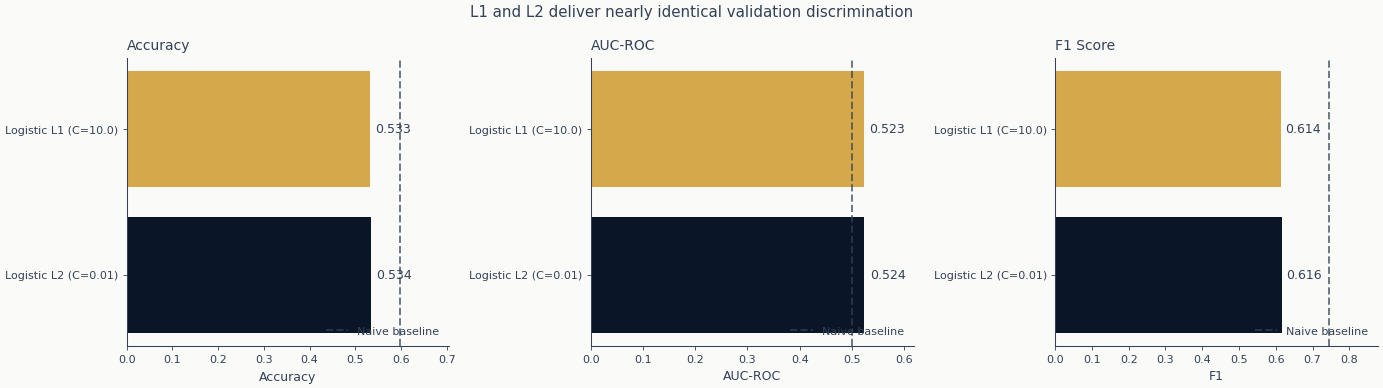

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

model_names = comparison["Model"].to_list()[:2]
x = np.arange(len(model_names))
bar_colors = [COLORS["blue"], COLORS["amber"]]
for ax, metric, title in zip(
    axes,
    ["Accuracy", "AUC-ROC", "F1"],
    ["Accuracy", "AUC-ROC", "F1 Score"],
    strict=False,
):
    vals = comparison[metric].to_list()[:2]
    bars = ax.barh(x, vals, color=bar_colors)
    for bar, val in zip(bars, vals, strict=False):
        ax.text(
            val + max(vals) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            fontsize=9,
        )
    ax.set_yticks(x)
    ax.set_yticklabels(model_names)
    ax.set_xlabel(metric)
    ax.set_title(title)
    baseline_value = comparison.filter(pl.col("Model") == "Naive (majority class)")[metric].item()
    ax.axvline(
        baseline_value,
        ls="--",
        color=COLORS["neutral"],
        alpha=0.7,
        label="Naive baseline",
    )
    ax.set_xlim(0, max(max(vals), baseline_value) * 1.18)
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("L1 and L2 deliver nearly identical validation discrimination")
fig.tight_layout()
fig.show()

The interpretation is computed from the comparison table. These are
cross-validation diagnostics, not a sealed final holdout estimate.

In [31]:
l2_row, l1_row, naive_row = comparison.iter_rows(named=True)
display(
    Markdown(
        f"L2 and L1 reach validation AUCs of **{l2_row['AUC-ROC']:.3f}** and "
        f"**{l1_row['AUC-ROC']:.3f}**, respectively, versus **0.500** for a constant "
        f"score. Their accuracies of **{l2_row['Accuracy']:.3f}** and "
        f"**{l1_row['Accuracy']:.3f}** remain below the majority-class baseline of "
        f"**{naive_row['Accuracy']:.3f}**. The features add little directional ranking "
        "power, and changing the penalty does not create a meaningfully different operating point."
    )
)

L2 and L1 reach validation AUCs of **0.524** and **0.523**, respectively, versus **0.500** for a constant score. Their accuracies of **0.534** and **0.533** remain below the majority-class baseline of **0.598**. The features add little directional ranking power, and changing the penalty does not create a meaningfully different operating point.

## Detailed Classification Analysis

We aggregate validation predictions across all walk-forward folds for the best L2 model
to examine the confusion matrix, ROC curve, and precision-recall tradeoff.

In [32]:
best_preds = l2_all[best_l2_C]["predictions"]

all_y_true = np.concatenate([p["y_true"] for p in best_preds])
all_y_prob = np.concatenate([p["y_prob"] for p in best_preds])
all_y_pred = (all_y_prob >= 0.5).astype(int)

### Confusion Matrix

In [33]:
cm = confusion_matrix(all_y_true, all_y_pred)
# sklearn returns rows = actual, cols = predicted: cm[i, j] = count(y_true=i, y_pred=j).
pl.DataFrame(
    {
        "Actual": ["Down", "Up"],
        "Predicted Down": [cm[0, 0], cm[1, 0]],
        "Predicted Up": [cm[0, 1], cm[1, 1]],
    }
)

Actual,Predicted Down,Predicted Up
str,i64,i64
"""Down""",24827,51777
"""Up""",36728,76879


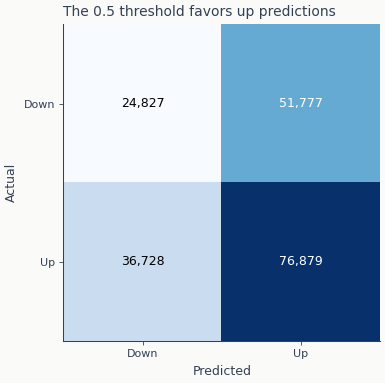

In [34]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Down", "Up"])
ax.set_yticklabels(["Down", "Up"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("The 0.5 threshold favors up predictions")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

fig.tight_layout()
fig.show()

The cell below quantifies how the fixed threshold changes the predicted base rate.

In [35]:
actual_up_rate = all_y_true.mean()
predicted_up_rate = all_y_pred.mean()
display(
    Markdown(
        f"The model predicts Up on **{predicted_up_rate:.1%}** of validation observations "
        f"versus a realized Up rate of **{actual_up_rate:.1%}**. This imbalance explains why "
        "false positives outnumber false negatives. Section 11.3 discusses choosing a trading "
        "threshold separately from estimating probabilities."
    )
)

The model predicts Up on **67.6%** of validation observations versus a realized Up rate of **59.7%**. This imbalance explains why false positives outnumber false negatives. Section 11.3 discusses choosing a trading threshold separately from estimating probabilities.

### ROC Curve

The ROC curve plots the true positive rate against the false positive rate
at various probability thresholds. An AUC above 0.5 indicates the model
does better than random coin-flipping.

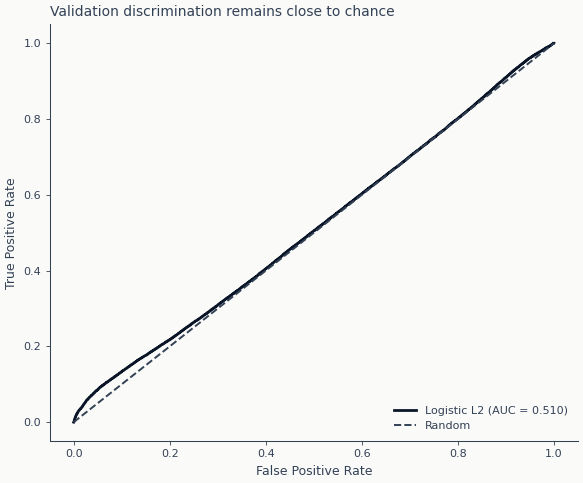

In [36]:
# Manual argsort+cumsum ROC sweep. sklearn's _binary_clf_curve raises a
# state-dependent IndexError on some score arrays under the pinned
# scikit-learn / numpy 2.x stack; this path is the exact ROC definition,
# deterministic, and equivalent on these scores.
auc_val = roc_auc_score(all_y_true, all_y_prob)
_order = np.argsort(-all_y_prob, kind="mergesort")
_yt_sorted = all_y_true[_order].astype(np.int64)
_n_pos = int(_yt_sorted.sum())
_n_neg = len(_yt_sorted) - _n_pos
fpr = np.concatenate([[0.0], np.cumsum(1 - _yt_sorted) / _n_neg])
tpr = np.concatenate([[0.0], np.cumsum(_yt_sorted) / _n_pos])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f"Logistic L2 (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color=COLORS["neutral"], label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation discrimination remains close to chance")
ax.legend(loc="lower right")
fig.tight_layout()
fig.show()

### Precision-Recall Curve

For imbalanced classes or when the cost of false positives is high,
the precision-recall curve is more informative than ROC.

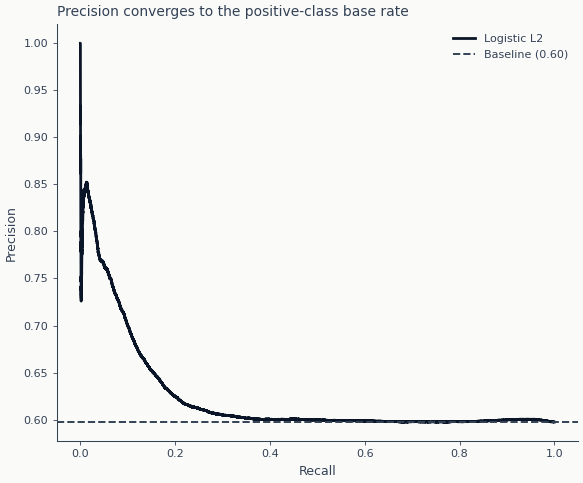

In [37]:
# Manual precision-recall sweep, same rationale as the ROC cell above.
_pr_order = np.argsort(-all_y_prob, kind="mergesort")
_pr_yt = all_y_true[_pr_order].astype(np.int64)
_tps = np.cumsum(_pr_yt)
prec = _tps / np.arange(1, len(_pr_yt) + 1)
rec = _tps / int(_pr_yt.sum())
baseline = all_y_true.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, linewidth=2, label="Logistic L2")
ax.axhline(baseline, ls="--", color=COLORS["neutral"], label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision converges to the positive-class base rate")
ax.legend()
fig.tight_layout()
fig.show()

## L1 Feature Importance

The L1 logistic model zeroes out unimportant features. Comparing the
surviving features with the LASSO regression results from NB02 shows
whether the same signals matter for direction prediction.

In [38]:
l1_coeffs = l1_all[best_l1_C]["coeffs"]  # (n_folds, n_features)
mean_abs = np.abs(l1_coeffs).mean(axis=0)
mean_signed = l1_coeffs.mean(axis=0)

importance = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "mean_abs_coeff": mean_abs,
        "mean_signed_coeff": mean_signed,
    }
).sort("mean_abs_coeff", descending=True)

nonzero = importance.filter(pl.col("mean_abs_coeff") > 1e-8)
print(f"Non-zero features: {nonzero.height}/{len(FEATURE_COLS)} at C={best_l1_C}")
nonzero.head(15)

Non-zero features: 57/57 at C=10.0


feature,mean_abs_coeff,mean_signed_coeff
str,f64,f64
"""vol_63d""",0.667202,-0.280187
"""vol_126d""",0.643474,0.241259
"""rsi_7""",0.338802,0.338802
"""sma_ratio_200""",0.337254,-0.324902
"""dist_52w_high""",0.268346,0.268346
…,…,…
"""rsi_14""",0.197502,-0.197502
"""max_dd_126d""",0.184246,0.177894
"""natr_14""",0.164509,0.164509


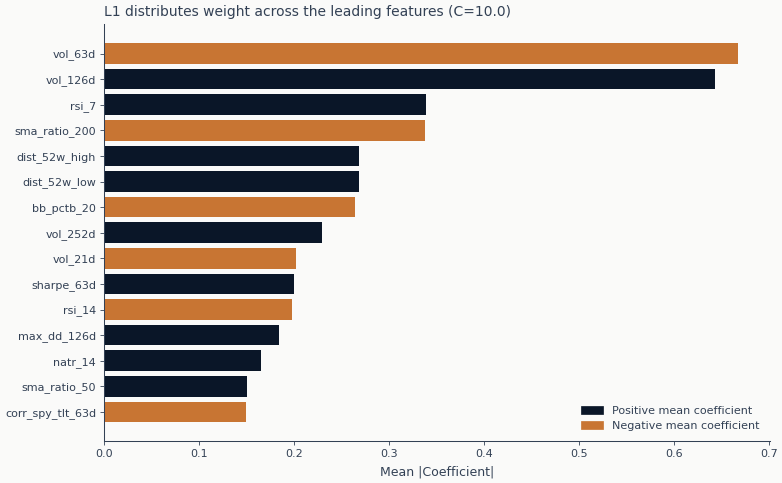

In [39]:
top15 = importance.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [
    COLORS["blue"] if v >= 0 else COLORS["copper"] for v in top15["mean_signed_coeff"].to_list()
]
ax.barh(range(len(top15)), top15["mean_abs_coeff"].to_list(), color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"].to_list())
ax.invert_yaxis()
ax.set_xlabel("Mean |Coefficient|")
ax.set_title(f"L1 distributes weight across the leading features (C={best_l1_C})")
ax.legend(
    handles=[
        Patch(color=COLORS["blue"], label="Positive mean coefficient"),
        Patch(color=COLORS["copper"], label="Negative mean coefficient"),
    ],
    loc="lower right",
)
fig.tight_layout()
fig.show()

## Probability Calibration

For a well-calibrated classifier, predicted probabilities should match
observed frequencies. If the model says "70% chance of going up," we
should see ~70% of those outcomes actually go up. Good calibration is
essential for converting probabilities into position sizes.

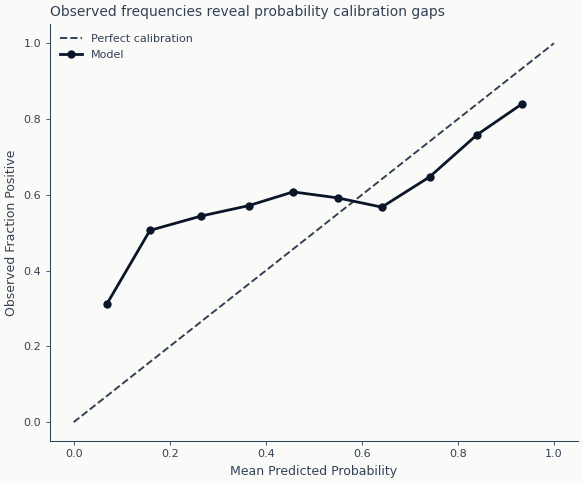

In [40]:
cal_fracs, cal_means = calibration_curve(all_y_true, all_y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], ls="--", color=COLORS["neutral"], label="Perfect calibration")
ax.plot(cal_means, cal_fracs, "o-", linewidth=2, markersize=6, label="Model")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction Positive")
ax.set_title("Observed frequencies reveal probability calibration gaps")
ax.legend()
fig.tight_layout()
fig.show()

**Interpretation**: A curve above the diagonal means the model is
under-confident (actual positive rate exceeds predicted probability),
while a curve below means over-confidence. The curve can still depart from the
diagonal even though logistic loss directly
optimizes probability estimates. The curve, not the model family, decides
whether confidence-based position sizing is defensible.

### Platt Scaling Correction

`CalibratedClassifierCV(method='sigmoid')` fits a logistic function to the
model's raw outputs - Platt scaling. Its internal folds must also respect
chronology. We therefore use expanding date blocks with a 21-session label purge,
then compare the original and corrected curves on the latest outer fold.

The inner calibration splitter keeps complete timestamp groups together. For a
21-session forward label, the last training label must mature strictly before the
first calibration timestamp.

In [41]:
def expanding_calibration_splits(
    dates: np.ndarray,
    n_splits: int = 3,
    gap_sessions: int = LABEL_HORIZON_SESSIONS,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Build expanding chronological splits for Platt calibration."""
    unique_dates = np.unique(dates)
    block_size = max(1, len(unique_dates) // 10)
    starts = np.linspace(int(0.55 * len(unique_dates)), int(0.85 * len(unique_dates)), n_splits)
    splits_out = []
    for start in starts.astype(int):
        validation_dates = unique_dates[start : min(start + block_size, len(unique_dates))]
        train_end = start - gap_sessions
        if train_end <= 0 or not len(validation_dates):
            continue
        train_dates = unique_dates[:train_end]
        label_end = unique_dates[train_end - 1 + gap_sessions]
        if label_end >= validation_dates[0]:
            raise ValueError("Calibration training labels overlap the validation block")
        train_local = np.flatnonzero(np.isin(dates, train_dates))
        validation_local = np.flatnonzero(np.isin(dates, validation_dates))
        splits_out.append((train_local, validation_local))
    return splits_out

In [42]:
tr_last, te_last = cv_splits[-1]
y_te_platt = target_array[te_last]

calibration_cv = expanding_calibration_splits(dates_np[tr_last])
base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_l2_C,
        solver="lbfgs",
        max_iter=MODEL_MAX_ITER,
        random_state=RANDOM_SEED,
    ),
)
cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv=calibration_cv)
cal_model.fit(features_array[tr_last], target_array[tr_last])
y_prob_platt = cal_model.predict_proba(features_array[te_last])[:, 1]

The comparison model uses the same outer training and validation rows. Its scaler
remains fold-local but receives no additional sigmoid calibration.

In [43]:
scaler_platt = StandardScaler()
X_tr_platt = scaler_platt.fit_transform(features_array[tr_last])
X_te_platt = scaler_platt.transform(features_array[te_last])
orig_model = LogisticRegression(
    C=best_l2_C,
    solver="lbfgs",
    max_iter=MODEL_MAX_ITER,
    random_state=RANDOM_SEED,
)
orig_model.fit(X_tr_platt, target_array[tr_last])
y_prob_orig = orig_model.predict_proba(X_te_platt)[:, 1]

frac_orig, mean_orig = calibration_curve(y_te_platt, y_prob_orig, n_bins=10)
frac_platt, mean_platt = calibration_curve(y_te_platt, y_prob_platt, n_bins=10)

The reliability diagram reveals how sigmoid calibration changes the latest-fold
probabilities. It does not assume that the correction must improve them.

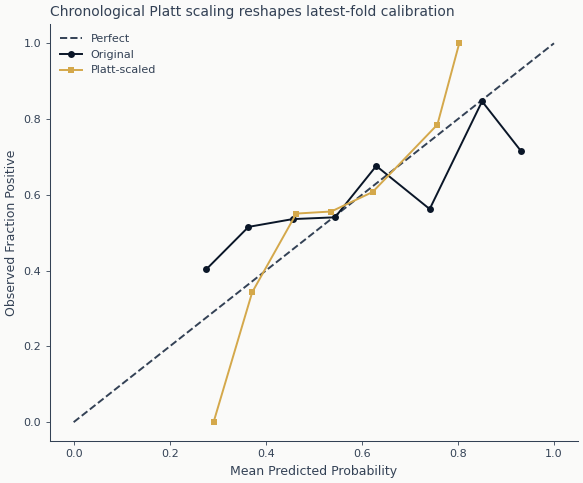

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], ls="--", color=COLORS["neutral"], label="Perfect")
ax.plot(mean_orig, frac_orig, "o-", label="Original", markersize=5)
ax.plot(mean_platt, frac_platt, "s-", label="Platt-scaled", markersize=5)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction Positive")
ax.set_title("Chronological Platt scaling reshapes latest-fold calibration")
ax.legend()
fig.tight_layout()
fig.show()

In [45]:
orig_log_loss = log_loss(y_te_platt, y_prob_orig)
platt_log_loss = log_loss(y_te_platt, y_prob_platt)
calibration_direction = "improves" if platt_log_loss < orig_log_loss else "worsens"
display(
    Markdown(
        f"On the latest outer fold, sigmoid calibration **{calibration_direction}** "
        f"log-loss from **{orig_log_loss:.4f}** to **{platt_log_loss:.4f}**. The curve "
        "still decides whether the revised probabilities support confidence-based sizing."
    )
)

On the latest outer fold, sigmoid calibration **improves** log-loss from **0.6988** to **0.6884**. The curve still decides whether the revised probabilities support confidence-based sizing.

### Hit Rate by Confidence

If the classifier is informative, accuracy should increase with prediction
confidence (distance from 0.5). We bin pooled out-of-sample predictions
by confidence and check for monotonicity.

In [46]:
confidence = np.abs(all_y_prob - 0.5)
bin_edges = np.quantile(confidence, np.linspace(0, 1, 6))
bin_edges[0] = -0.001  # include zero
bin_labels = np.clip(np.digitize(confidence, bin_edges) - 1, 0, 4)

hit_rows = []
for b in range(5):
    mask = bin_labels == b
    if mask.sum() > 0:
        acc = (all_y_pred[mask] == all_y_true[mask]).mean()
        hit_rows.append(
            {
                "quintile": b + 1,
                "confidence": f"{bin_edges[b]:.3f}-{bin_edges[b + 1]:.3f}",
                "n_samples": int(mask.sum()),
                "accuracy": round(acc, 4),
            }
        )

hit_table = pl.DataFrame(hit_rows)
hit_table

quintile,confidence,n_samples,accuracy
i64,str,i64,f64
1,"""-0.001-0.030""",38042,0.5038
2,"""0.030-0.063""",38042,0.5143
3,"""0.063-0.100""",38042,0.5205
4,"""0.100-0.153""",38042,0.5263
5,"""0.153-0.499""",38043,0.6085


The generated interpretation compares the highest-confidence bucket with the
lower four without assuming that a previous vintage's pattern persists.

In [47]:
hit_rows_named = list(hit_table.iter_rows(named=True))
lower_accuracies = [row["accuracy"] for row in hit_rows_named[:4]]
top_hit = hit_rows_named[-1]
top_share = top_hit["n_samples"] / hit_table["n_samples"].sum()
display(
    Markdown(
        f"Accuracy spans **{min(lower_accuracies):.1%}-{max(lower_accuracies):.1%}** across "
        f"the lower four confidence quintiles and reaches **{top_hit['accuracy']:.1%}** in "
        f"the highest-confidence quintile. Restricting decisions to that bucket retains "
        f"**{top_share:.1%}** of observations. The threshold therefore trades breadth for a "
        "higher observed hit rate, but the irregular lower buckets warn against treating raw "
        "probability distance as a perfectly ordered strength signal."
    )
)

Accuracy spans **50.4%-52.6%** across the lower four confidence quintiles and reaches **60.9%** in the highest-confidence quintile. Restricting decisions to that bucket retains **20.0%** of observations. The threshold therefore trades breadth for a higher observed hit rate, but the irregular lower buckets warn against treating raw probability distance as a perfectly ordered strength signal.

### From Probabilities to Trading Signals

The same model produces different portfolios depending on how probabilities
are converted to positions. We demonstrate three common approaches on the
last fold: threshold-based, probability-weighted, and rank-based.

In [48]:
last_prob = l2_all[best_l2_C]["predictions"][-1]["y_prob"]
n_sig = len(last_prob)

# Three conversion methods
thresh_long = last_prob > 0.55
thresh_short = last_prob < 0.45
prob_signal = last_prob - 0.5
ranks = np.argsort(np.argsort(last_prob)) / n_sig
rank_long = ranks >= 0.8
rank_short = ranks < 0.2

print(f"Last fold: {n_sig:,} predictions\n")
print(
    f"Threshold (0.45/0.55): {thresh_long.sum():,} long, {thresh_short.sum():,} short, {(~thresh_long & ~thresh_short).sum():,} flat"
)
print(f"Rank-based (20/20):    {rank_long.sum():,} long, {rank_short.sum():,} short")
print(f"Prob-weighted:         all {n_sig:,} have non-zero weight (mean: {prob_signal.mean():.4f})")
overlap = (thresh_long & rank_long).sum()
print(
    f"\nThreshold-long ∩ rank-long overlap: {overlap}/{thresh_long.sum()} ({overlap / max(thresh_long.sum(), 1):.0%})"
)

Last fold: 24,190 predictions

Threshold (0.45/0.55): 6,248 long, 7,681 short, 10,261 flat
Rank-based (20/20):    4,838 long, 4,838 short
Prob-weighted:         all 24,190 have non-zero weight (mean: -0.0069)

Threshold-long ∩ rank-long overlap: 4838/6248 (77%)


The three methods produce substantially different portfolios from the same
predictions. The choice depends on strategy constraints (position limits,
turnover targets, liquidity). Chapter 17 develops the full framework.

## Multinomial Extension: Ternary Direction

Binary up/down discards information about return magnitude. A multinomial
logistic model with three classes (bottom/middle/top tercile) retains the
ordinal structure and maps naturally to the softmax formulation in Section 11.3.

In [49]:
tr_last, te_last = cv_splits[-1]
y_ret_train = return_array[tr_last]
y_ret_test = return_array[te_last]

tercile_edges = np.quantile(y_ret_train, [1 / 3, 2 / 3])
y_tern_train = np.digitize(y_ret_train, tercile_edges)  # 0=bottom, 1=mid, 2=top
y_tern_test = np.digitize(y_ret_test, tercile_edges)

scaler_mn = StandardScaler()
X_tr_mn = scaler_mn.fit_transform(features_array[tr_last])
X_te_mn = scaler_mn.transform(features_array[te_last])

model_mn = LogisticRegression(
    solver="lbfgs",
    C=best_l2_C,
    max_iter=MODEL_MAX_ITER,
    random_state=RANDOM_SEED,
)
model_mn.fit(X_tr_mn, y_tern_train)
y_pred_mn = model_mn.predict(X_te_mn)

ternary_report = classification_report(
    y_tern_test,
    y_pred_mn,
    target_names=["Bottom", "Middle", "Top"],
    output_dict=True,
    zero_division=0,
)
pl.DataFrame(
    [
        {"class": name, **ternary_report[name]}
        for name in ["Bottom", "Middle", "Top", "macro avg", "weighted avg"]
    ]
)

class,precision,recall,f1-score,support
str,f64,f64,f64,f64
"""Bottom""",0.430386,0.698183,0.532512,9413.0
"""Middle""",0.512063,0.357019,0.420711,6361.0
"""Top""",0.464437,0.247505,0.322921,8416.0
"""macro avg""",0.468962,0.434236,0.425381,24190.0
"""weighted avg""",0.463711,0.451674,0.430194,24190.0


The class-level interpretation is generated from the current latest fold.

In [50]:
top_metrics = ternary_report["Top"]
bottom_metrics = ternary_report["Bottom"]
display(
    Markdown(
        f"Latest-fold ternary accuracy is **{ternary_report['accuracy']:.1%}** versus a "
        f"one-third random reference. Top-tercile recall is **{top_metrics['recall']:.1%}** "
        f"and Bottom-tercile recall is **{bottom_metrics['recall']:.1%}**. The asymmetric "
        "errors show that a vanilla multinomial loss does not recover return extremes evenly; "
        "class reweighting, an ordinal objective, or a cross-sectional rank mapping would encode "
        "that trading objective more directly."
    )
)

Latest-fold ternary accuracy is **45.2%** versus a one-third random reference. Top-tercile recall is **24.8%** and Bottom-tercile recall is **69.8%**. The asymmetric errors show that a vanilla multinomial loss does not recover return extremes evenly; class reweighting, an ordinal objective, or a cross-sectional rank mapping would encode that trading objective more directly.

## Key Takeaways

1. **Direction prediction** reframes the return forecasting problem as binary
   classification. The majority-class baseline remains a demanding accuracy
   reference because positive 21-day ETF returns are more common.

2. **L2 logistic regression** keeps all features and is well-suited when many
   correlated signals each contribute a small amount. L1 can create sparsity
   under stronger regularization, but the AUC-optimal fit retains most features.

3. **AUC-ROC** is more informative than raw accuracy because it evaluates
   discrimination across all probability thresholds. Here it remains close to
   the constant-score reference, so the exercise demonstrates workflow rather
   than a deployable directional edge.

4. **Probability calibration** matters for position sizing. The reliability
   diagrams show gaps between predicted probabilities and observed frequencies.
   Chronological Platt scaling reshapes those probabilities but does not guarantee
   improvement, so evaluate calibration on data that follows every fitted step.

5. **Walk-forward validation is not a final holdout.** These folds support model
   comparison and diagnostics; a sealed holdout is required for a final strategy claim.

**Next**: `04_nested_cv_hpo` adds Optuna-based hyperparameter optimization
with proper nested cross-validation to control selection bias.